# Canadian Community Health Survey — Predictive Analysis


This notebook implements a reproducible analysis pipeline for survey-derived determinants of life satisfaction. It includes:

- Data ingestion and deterministic cleaning
- Focused exploratory data analysis with clear visual frames
- Preprocessing pipelines designed to avoid leakage
- Baseline and ensemble regression models with standardized evaluation
- A compact Streamlit interface for interactive review

**Dataset:** health_dataset.csv • **Target:** Life_satisfaction

Reproducibility: all preprocessing used for modelling is encapsulated in sklearn pipelines and the train/test split is fixed (random_state=42).

In [30]:
import pandas as pd
import numpy as np

# remove warning userwarnings
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("health_dataset.csv")

# Keep only selected columns
cols = [
    "Life_satisfaction",
    "Age",
    "Gender",
    "Marital_status",
    "Edu_level",
    "Total_income",
    "Gen_health_state",
    "Mental_health_state",
    "Stress_level",
    "Total_physical_act_time",
    "Smoked"
]

df = df[cols].copy()

# Replace common "not stated / don't know" codes with NaN
invalid_codes = [6, 7, 8, 9, 96, 97, 98, 99, 996, 997, 998, 999, 9996, 9997, 9998, 9999]
df.replace(invalid_codes, np.nan, inplace=True)

# ---- Map coded values to readable labels ---- #

df["Gender"] = df["Gender"].map({1: "Male", 2: "Female"})

df["Marital_status"] = df["Marital_status"].map({
    1: "Married/Common-law",
    2: "Single/Other"
})

df["Edu_level"] = df["Edu_level"].map({
    1: "Less than secondary",
    2: "Secondary graduate",
    3: "Post-secondary"
})

df["Total_income"] = df["Total_income"].map({
    1: "< $20k",
    2: "$20k–$40k",
    3: "$40k–$60k",
    4: "$60k–$80k",
    5: "$80k+"
})

df["Gen_health_state"] = df["Gen_health_state"].map({
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
})

df["Mental_health_state"] = df["Mental_health_state"].map({
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
})

df["Stress_level"] = df["Stress_level"].map({
    1: "Not at all stressful",
    2: "Not very stressful",
    3: "Somewhat stressful",
    4: "Very stressful",
    5: "Extremely stressful"
})

df["Smoked"] = df["Smoked"].map({
    1: "Yes",
    2: "No"
})

# Drop rows with missing target
df_clean = df.dropna(subset=["Life_satisfaction"]).reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)
df_clean.head()


Cleaned shape: (31771, 11)


,Life_satisfaction,Age,Gender,Marital_status,Edu_level,Total_income,Gen_health_state,Mental_health_state,Stress_level,Total_physical_act_time,Smoked
0,4.0,5,Male,Married/Common-law,Secondary graduate,$60k–$80k,Good,Good,Somewhat stressful,0.0,NaN
1,0.0,4,Male,Single/Other,Post-secondary,< $20k,Poor,Poor,Very stressful,NaN,NaN
2,10.0,5,Male,Single/Other,Secondary graduate,$40k–$60k,Very good,Excellent,Not at all stressful,NaN,NaN
3,10.0,5,Male,Married/Common-law,Post-secondary,$80k+,Very good,Excellent,Not at all stressful,NaN,NaN
4,10.0,2,Female,Married/Common-law,Post-secondary,$40k–$60k,Very good,Very good,Somewhat stressful,NaN,NaN


## Data loading & cleaning

Purpose: produce a defensible analysis dataset while preserving provenance.

Steps performed:
- Read CSV and retain a constrained set of variables relevant to the objective.
- Replace sentinel codes (various 6/7/8/9/96/997/etc.) with NaN so missingness is explicit.
- Map coded categories to descriptive labels for readability in plots and downstream processing.
- Drop records with a missing target (Life_satisfaction) and reset the index — result stored as `df_clean`.

Notes: mappings are deterministic and applied in-place; retain the original `df` if raw provenance is required.

In [31]:
# Basic overview
df_clean.info()

# Summary statistics for numeric columns
df_clean.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31771 entries, 0 to 31770
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Life_satisfaction        31771 non-null  float64
 1   Age                      31771 non-null  int64  
 2   Gender                   31771 non-null  object 
 3   Marital_status           29468 non-null  object 
 4   Edu_level                29795 non-null  object 
 5   Total_income             31057 non-null  object 
 6   Gen_health_state         31706 non-null  object 
 7   Mental_health_state      31707 non-null  object 
 8   Stress_level             31658 non-null  object 
 9   Total_physical_act_time  6033 non-null   float64
 10  Smoked                   300 non-null    object 
dtypes: float64(2), int64(1), object(8)
memory usage: 2.7+ MB


,Life_satisfaction,Age,Total_physical_act_time
count,31771.000000,31771.000000,6033.000000
mean,8.379308,3.921595,78.370131
std,2.721936,1.301505,182.994007
min,0.000000,1.000000,0.000000
25%,5.000000,3.000000,0.000000
50%,10.000000,4.000000,0.000000
75%,10.000000,5.000000,80.000000
max,10.000000,5.000000,3360.000000


## Exploratory data analysis — visual protocol

Objective: use concise, high-information plots to surface distributions, group differences and pairwise relationships prior to modelling.

Recommended visual checks:
- Target distribution: histogram + KDE — check skew and multimodality.
- Categorical breakdowns: countplots and grouped boxplots to gauge between-group shifts in the target.
- Numeric relationships: scatter plots and correlation heatmap for linear signals.

Interpretation checklist: identify outliers, heteroskedastic patterns, monotonic trends and whether transformations are needed.

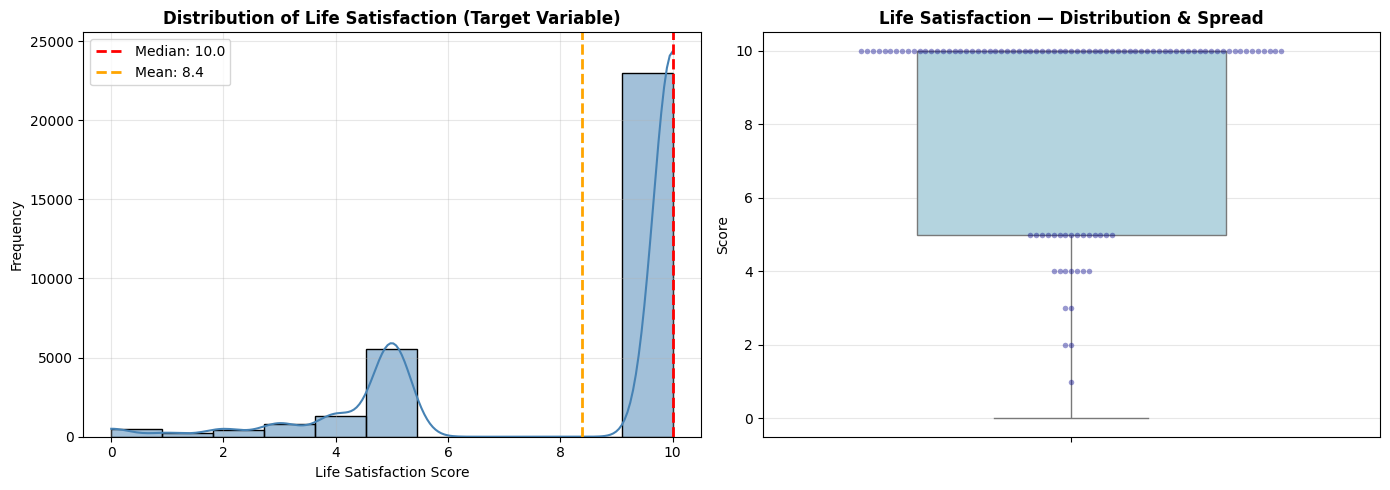

Skewness: -1.302
Kurtosis: 0.306


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Enhanced target distribution with quartile annotations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df_clean["Life_satisfaction"], bins=11, kde=True, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of Life Satisfaction (Target Variable)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Life Satisfaction Score", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].axvline(df_clean["Life_satisfaction"].median(), color="red", linestyle="--", linewidth=2, label=f"Median: {df_clean['Life_satisfaction'].median():.1f}")
axes[0].axvline(df_clean["Life_satisfaction"].mean(), color="orange", linestyle="--", linewidth=2, label=f"Mean: {df_clean['Life_satisfaction'].mean():.1f}")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot with swarm sample
sample_size = min(100, len(df_clean))
sns.boxplot(y=df_clean["Life_satisfaction"], ax=axes[1], color="lightblue", width=0.5)
sns.swarmplot(y=df_clean["Life_satisfaction"].sample(sample_size, random_state=42), ax=axes[1], color="darkblue", alpha=0.4, size=4)
axes[1].set_title("Life Satisfaction — Distribution & Spread", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Score", fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Skewness: {df_clean['Life_satisfaction'].skew():.3f}")
print(f"Kurtosis: {df_clean['Life_satisfaction'].kurtosis():.3f}")

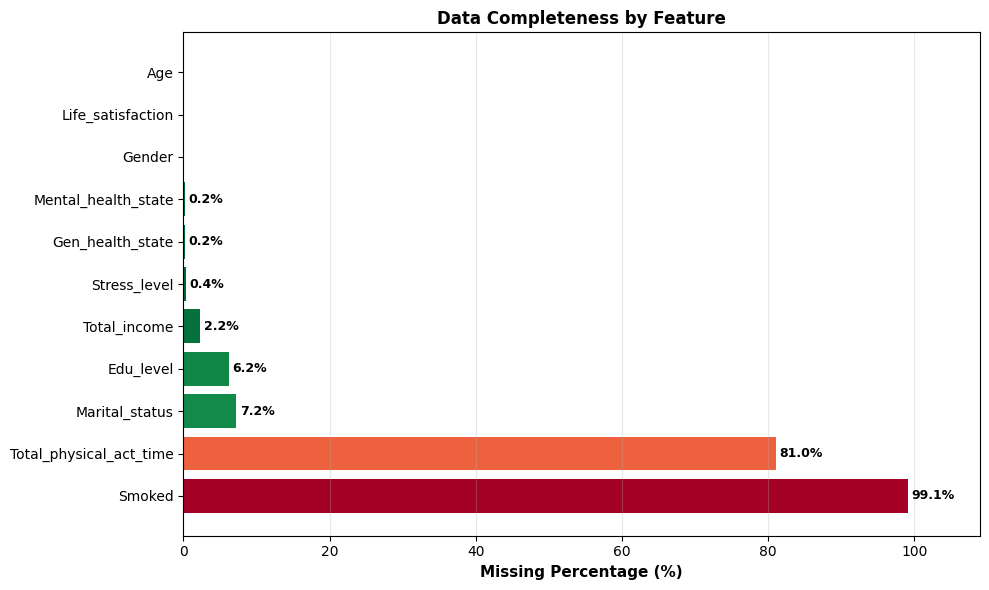


Missing Values Summary:
Smoked                     99.055743
Total_physical_act_time    81.010985
Marital_status              7.248749
Edu_level                   6.219508
Total_income                2.247332
Stress_level                0.355670
Gen_health_state            0.204589
Mental_health_state         0.201442
dtype: float64


In [33]:
# Enhanced missing values visualization with percentage labels
missing_pct = df_clean.isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_pct.index, missing_pct.values, color=plt.cm.RdYlGn_r(missing_pct.values / missing_pct.max()))
ax.set_xlabel("Missing Percentage (%)", fontsize=11, fontweight="bold")
ax.set_title("Data Completeness by Feature", fontsize=12, fontweight="bold")
ax.set_xlim(0, max(missing_pct.values) * 1.1)

# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars, missing_pct.values)):
    if val > 0:
        ax.text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMissing Values Summary:")
print(missing_pct[missing_pct > 0])

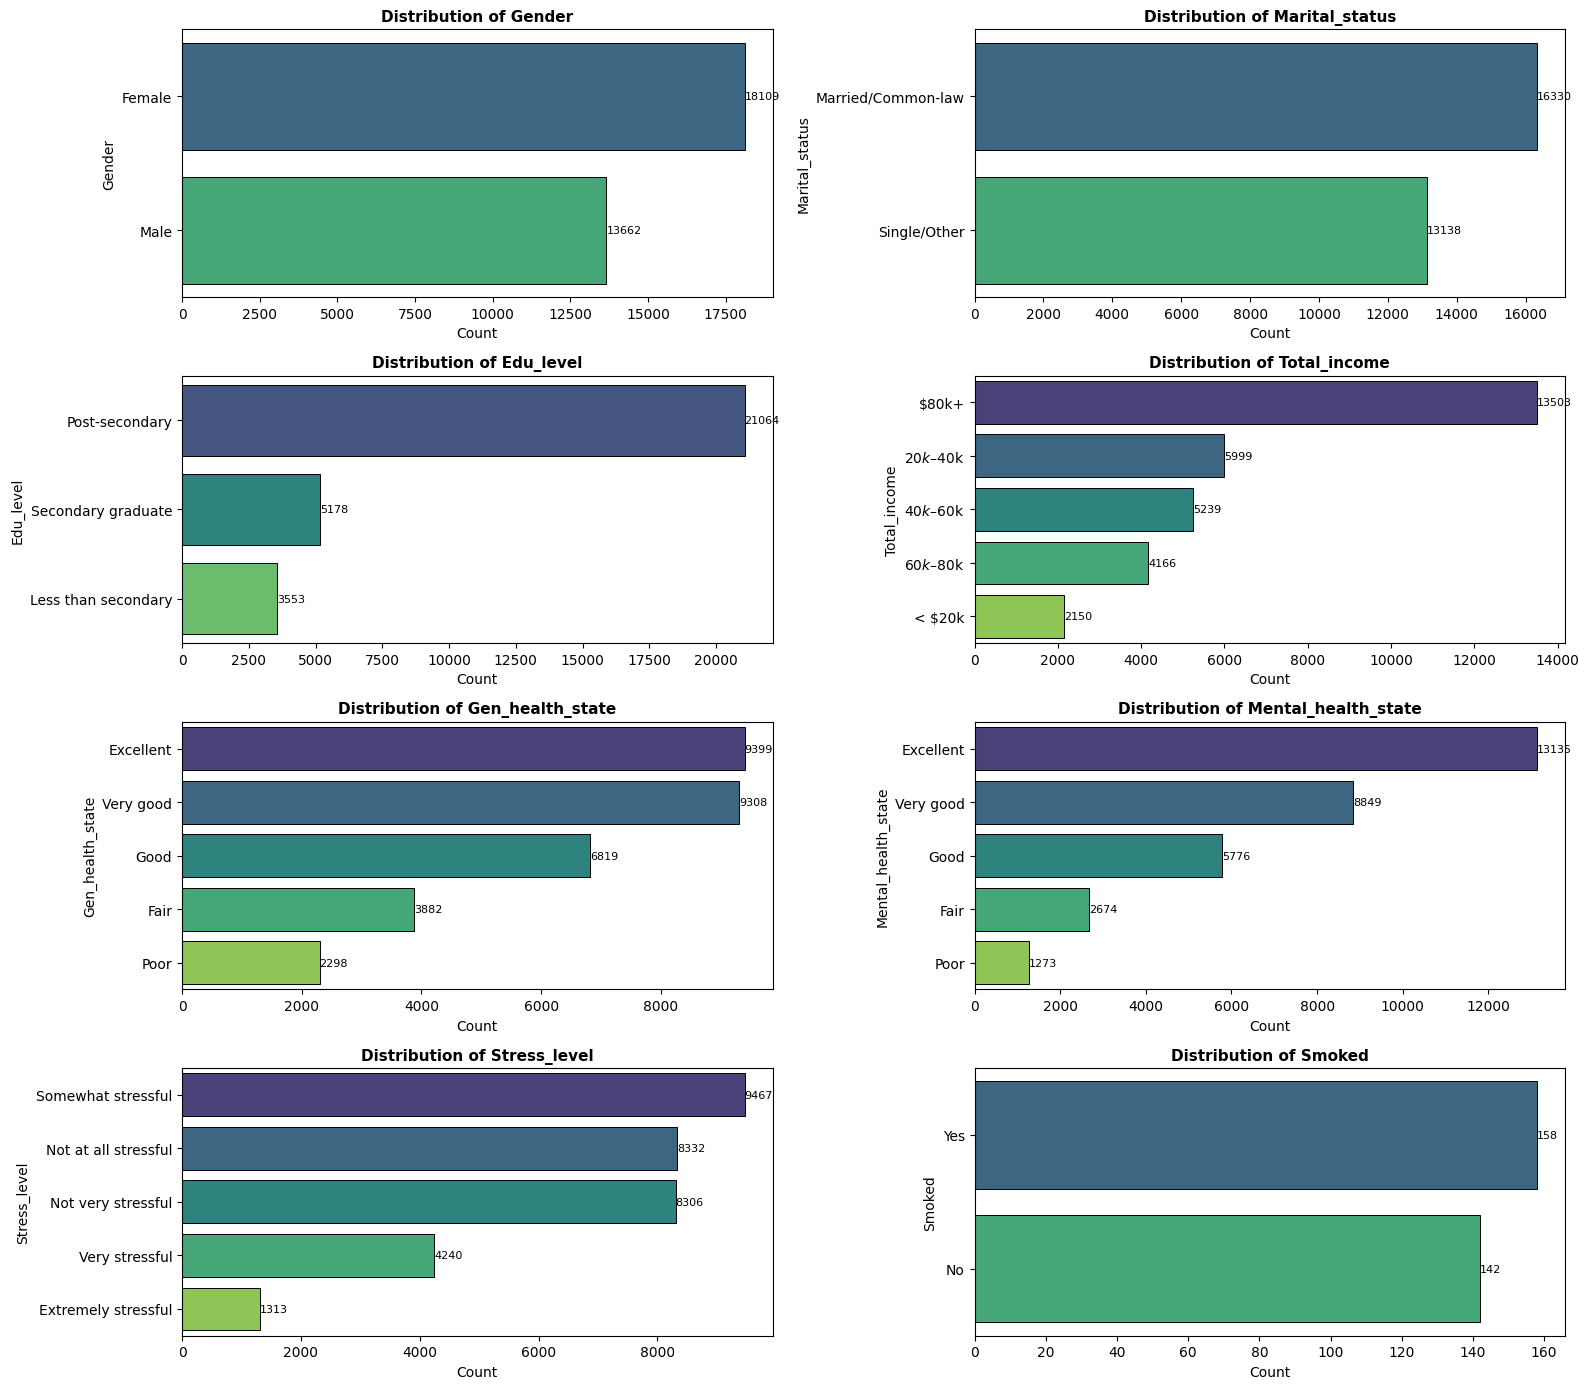

In [34]:
# Enhanced categorical distributions with target overlap
cat_cols = [
    "Gender", "Marital_status", "Edu_level",
    "Total_income", "Gen_health_state",
    "Mental_health_state", "Stress_level", "Smoked"
]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    # Count plot with color gradient
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=axes[idx], 
                  palette="viridis", edgecolor="black", linewidth=0.7)
    axes[idx].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Count", fontsize=10)
    
    # Add count labels
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()

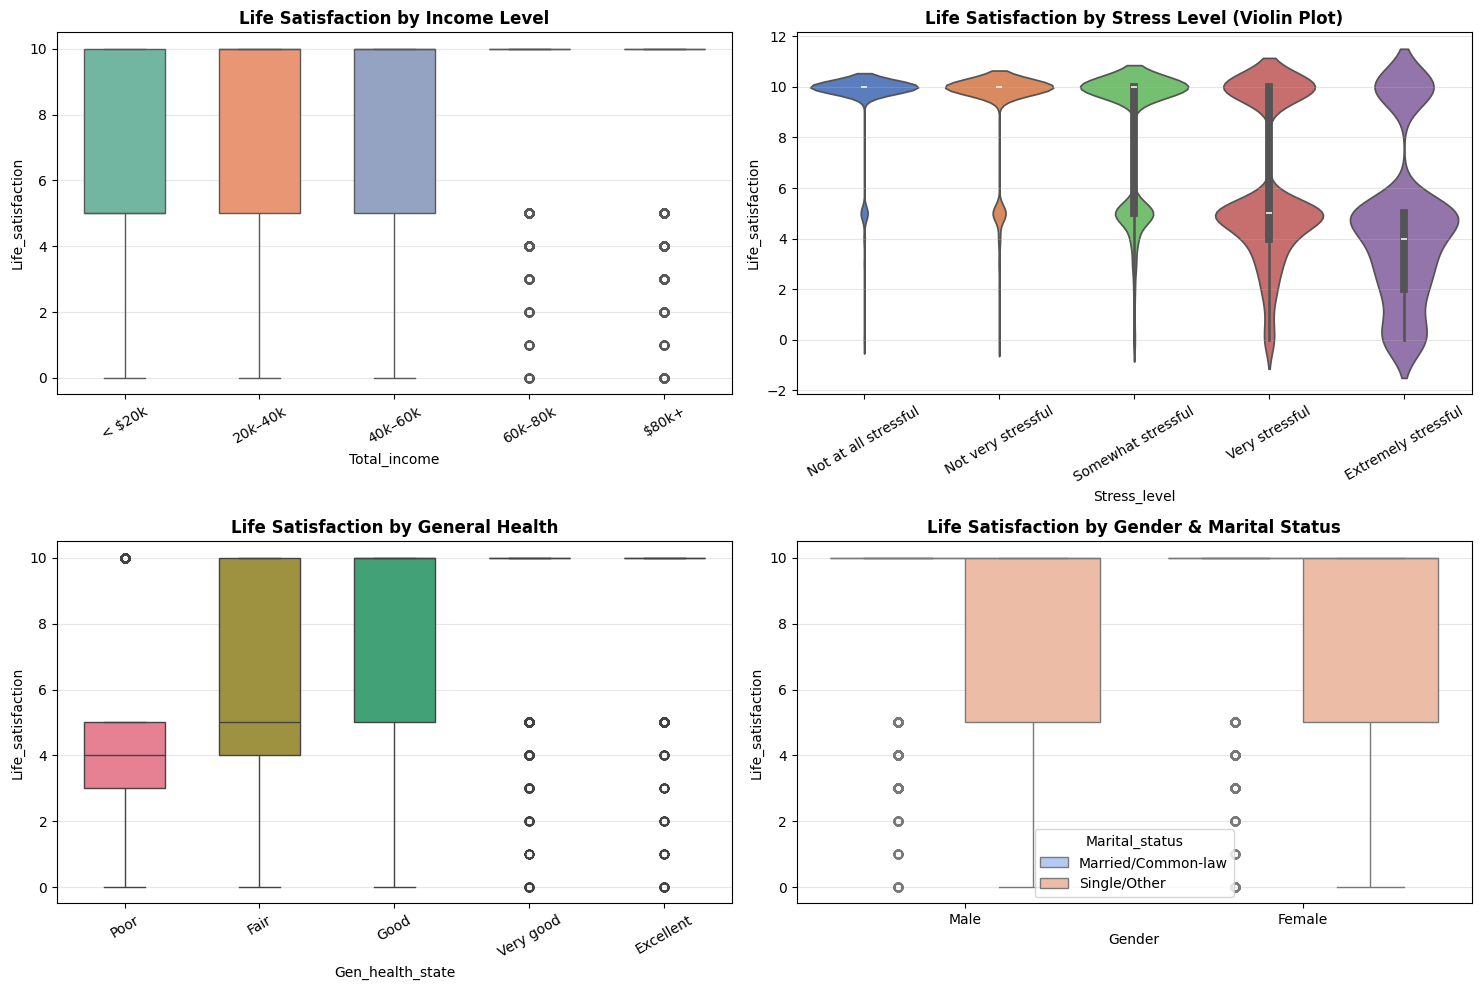

In [35]:
# New: Multivariate EDA — Life Satisfaction by Key Demographic Groups
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Income vs Life Satisfaction
income_order = ["< $20k", "$20k–$40k", "$40k–$60k", "$60k–$80k", "$80k+"]
sns.boxplot(data=df_clean, x="Total_income", y="Life_satisfaction", 
            order=income_order, ax=axes[0, 0], palette="Set2", width=0.6)
axes[0, 0].set_title("Life Satisfaction by Income Level", fontsize=12, fontweight="bold")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].grid(axis="y", alpha=0.3)

# Stress vs Life Satisfaction
stress_order = ["Not at all stressful", "Not very stressful", "Somewhat stressful", "Very stressful", "Extremely stressful"]
sns.violinplot(data=df_clean, x="Stress_level", y="Life_satisfaction", 
               order=stress_order, ax=axes[0, 1], palette="muted")
axes[0, 1].set_title("Life Satisfaction by Stress Level (Violin Plot)", fontsize=12, fontweight="bold")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].grid(axis="y", alpha=0.3)

# Health vs Life Satisfaction
health_order = ["Poor", "Fair", "Good", "Very good", "Excellent"]
sns.boxplot(data=df_clean, x="Gen_health_state", y="Life_satisfaction", 
            order=health_order, ax=axes[1, 0], palette="husl", width=0.6)
axes[1, 0].set_title("Life Satisfaction by General Health", fontsize=12, fontweight="bold")
axes[1, 0].tick_params(axis="x", rotation=30)
axes[1, 0].grid(axis="y", alpha=0.3)

# Gender & Marital Status Interaction
sns.boxplot(data=df_clean, x="Gender", y="Life_satisfaction", hue="Marital_status", 
            ax=axes[1, 1], palette="coolwarm")
axes[1, 1].set_title("Life Satisfaction by Gender & Marital Status", fontsize=12, fontweight="bold")
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

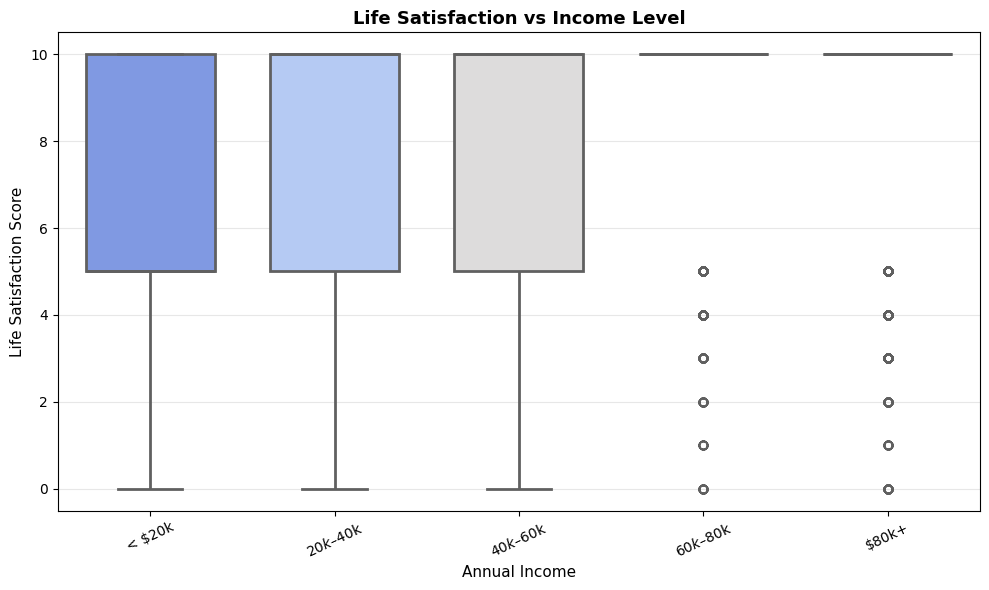

In [36]:
plt.figure(figsize=(10, 6))
income_order = ["< $20k", "$20k–$40k", "$40k–$60k", "$60k–$80k", "$80k+"]
sns.boxplot(data=df_clean, x="Total_income", y="Life_satisfaction", 
            order=income_order, palette="coolwarm", width=0.7, linewidth=2)
plt.title("Life Satisfaction vs Income Level", fontsize=13, fontweight="bold")
plt.xlabel("Annual Income", fontsize=11)
plt.ylabel("Life Satisfaction Score", fontsize=11)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


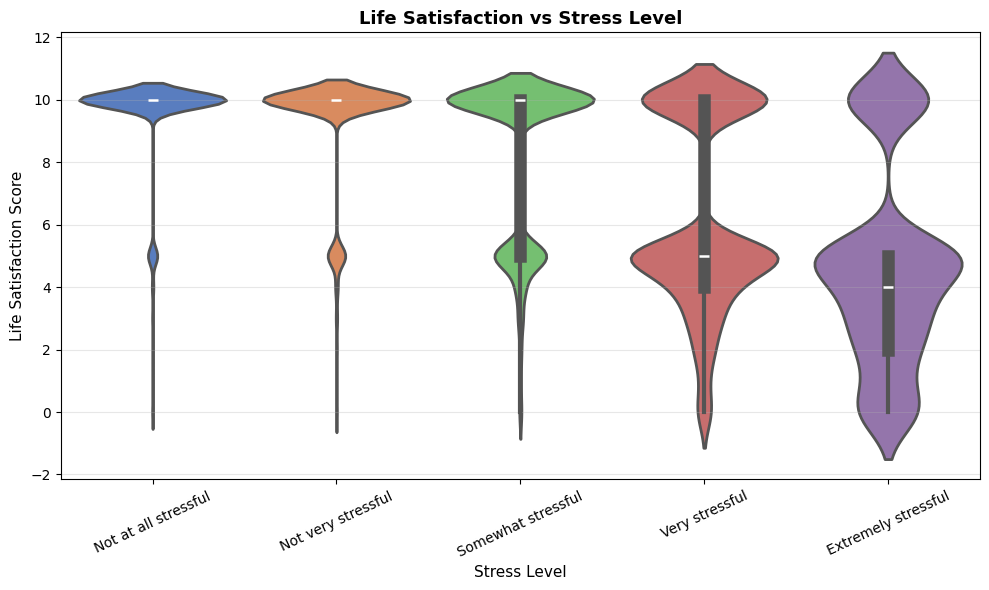

In [37]:
plt.figure(figsize=(10, 6))
stress_order = ["Not at all stressful", "Not very stressful", "Somewhat stressful", "Very stressful", "Extremely stressful"]
sns.violinplot(data=df_clean, x="Stress_level", y="Life_satisfaction", 
               order=stress_order, palette="muted", inner="box", linewidth=2)
plt.title("Life Satisfaction vs Stress Level", fontsize=13, fontweight="bold")
plt.xlabel("Stress Level", fontsize=11)
plt.ylabel("Life Satisfaction Score", fontsize=11)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


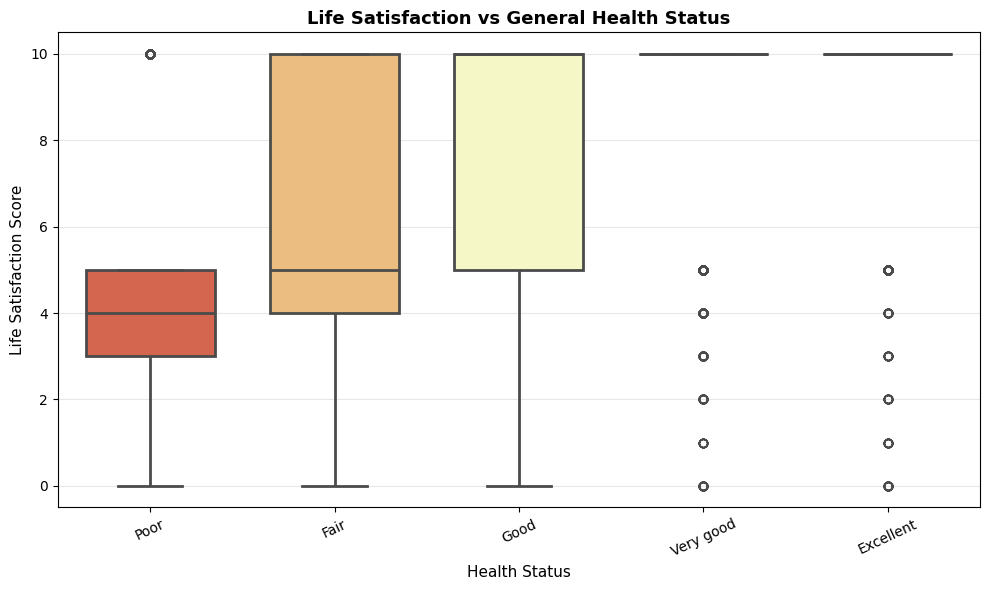

In [38]:
plt.figure(figsize=(10, 6))
health_order = ["Poor", "Fair", "Good", "Very good", "Excellent"]
sns.boxplot(data=df_clean, x="Gen_health_state", y="Life_satisfaction", 
            order=health_order, palette="RdYlGn", width=0.7, linewidth=2)
plt.title("Life Satisfaction vs General Health Status", fontsize=13, fontweight="bold")
plt.xlabel("Health Status", fontsize=11)
plt.ylabel("Life Satisfaction Score", fontsize=11)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


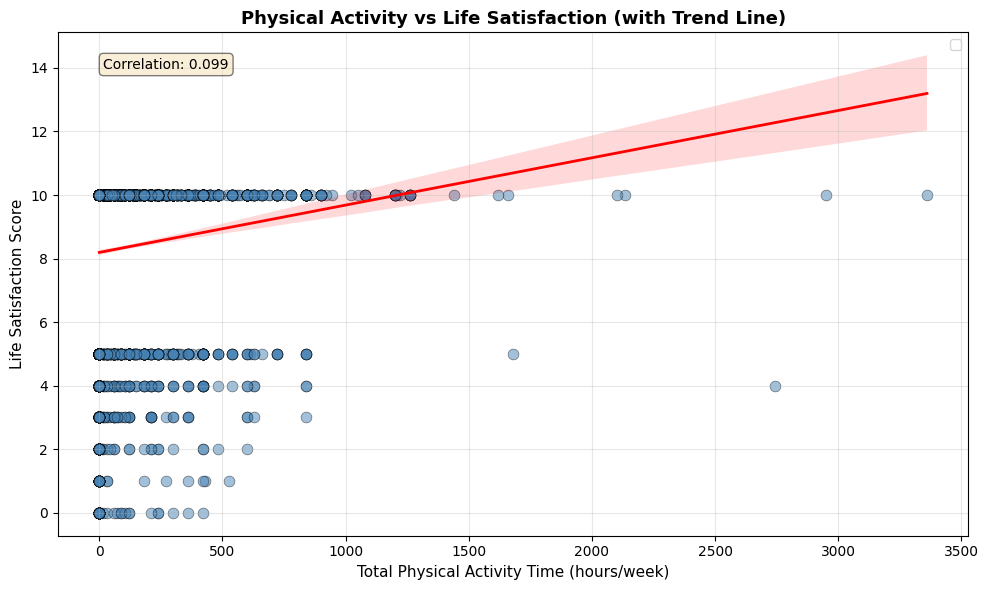

In [39]:
# Enhanced scatter plot with regression line and density
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter with transparency and size by density
sns.scatterplot(data=df_clean, x="Total_physical_act_time", y="Life_satisfaction",
                alpha=0.5, s=60, color="steelblue", ax=ax, edgecolor="black", linewidth=0.5)

# Add regression line
sns.regplot(data=df_clean, x="Total_physical_act_time", y="Life_satisfaction",
            scatter=False, line_kws={"color": "red", "linewidth": 2, "label": "Trend"}, ax=ax)

ax.set_title("Physical Activity vs Life Satisfaction (with Trend Line)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Physical Activity Time (hours/week)", fontsize=11)
ax.set_ylabel("Life Satisfaction Score", fontsize=11)
ax.grid(alpha=0.3)
ax.legend()

# Add correlation coefficient
corr = df_clean[["Total_physical_act_time", "Life_satisfaction"]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f"Correlation: {corr:.3f}", transform=ax.transAxes,
        fontsize=10, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()


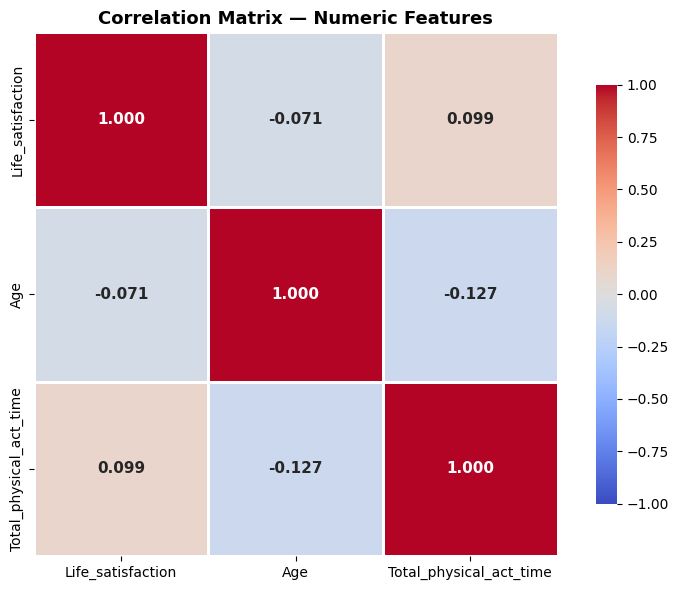

In [40]:
# Enhanced correlation heatmap with annotations
num_cols = ["Life_satisfaction", "Age", "Total_physical_act_time"]
corr_matrix = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1, annot_kws={"fontsize": 11, "fontweight": "bold"})
ax.set_title("Correlation Matrix — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# New: Feature Importance from Random Forest Model
import matplotlib.pyplot as plt
import rf_model

# Extract feature importance from the trained Random Forest model
feature_importance = rf_model.named_steps['model'].feature_importances_
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], 
               color=plt.cm.viridis(importance_df['Importance'] / importance_df['Importance'].max()),
               edgecolor="black", linewidth=1.2)
ax.set_xlabel("Importance Score", fontsize=11, fontweight="bold")
ax.set_title("Top 15 Feature Importance (Random Forest Model)", fontsize=13, fontweight="bold")
ax.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, importance_df['Importance'])):
    ax.text(val + 0.002, i, f"{val:.4f}", va="center", fontsize=9, fontweight="bold")

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'rf_model' is not defined

NameError: name 'y_test' is not defined

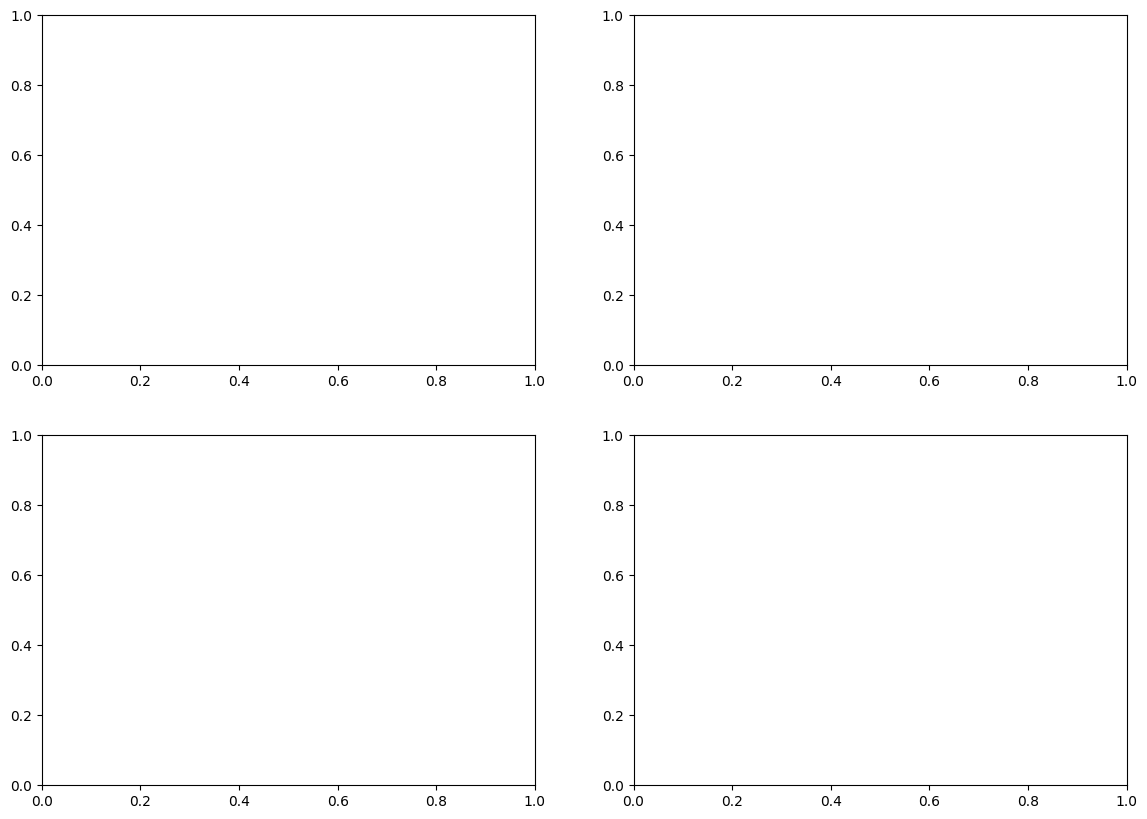

In [42]:
# New: Model Residual Diagnostics for Best Model (Gradient Boosting)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals
residuals = y_test - y_pred_gb

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred_gb, residuals, alpha=0.5, edgecolor="black", linewidth=0.5)
axes[0, 0].axhline(y=0, color="r", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("Predicted Values", fontsize=10, fontweight="bold")
axes[0, 0].set_ylabel("Residuals", fontsize=10, fontweight="bold")
axes[0, 0].set_title("Residuals vs Predicted (Homoscedasticity Check)", fontsize=11, fontweight="bold")
axes[0, 0].grid(alpha=0.3)

# 2. Histogram of Residuals
axes[0, 1].hist(residuals, bins=30, edgecolor="black", color="steelblue", alpha=0.7)
axes[0, 1].axvline(x=0, color="r", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Residuals", fontsize=10, fontweight="bold")
axes[0, 1].set_ylabel("Frequency", fontsize=10, fontweight="bold")
axes[0, 1].set_title("Distribution of Residuals (Normality Check)", fontsize=11, fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot (Normality Assessment)", fontsize=11, fontweight="bold")
axes[1, 0].grid(alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred_gb, alpha=0.5, edgecolor="black", linewidth=0.5, label="Predictions")
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label="Perfect Prediction")
axes[1, 1].set_xlabel("Actual Values", fontsize=10, fontweight="bold")
axes[1, 1].set_ylabel("Predicted Values", fontsize=10, fontweight="bold")
axes[1, 1].set_title("Actual vs Predicted (Calibration)", fontsize=11, fontweight="bold")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print residual statistics
print("Residual Diagnostics:")
print(f"Mean of Residuals: {residuals.mean():.4f} (should be ~0)")
print(f"Std of Residuals: {residuals.std():.4f}")
print(f"Skewness: {residuals.skew():.4f}")
print(f"Kurtosis: {residuals.kurtosis():.4f}")

NameError: name 'results' is not defined

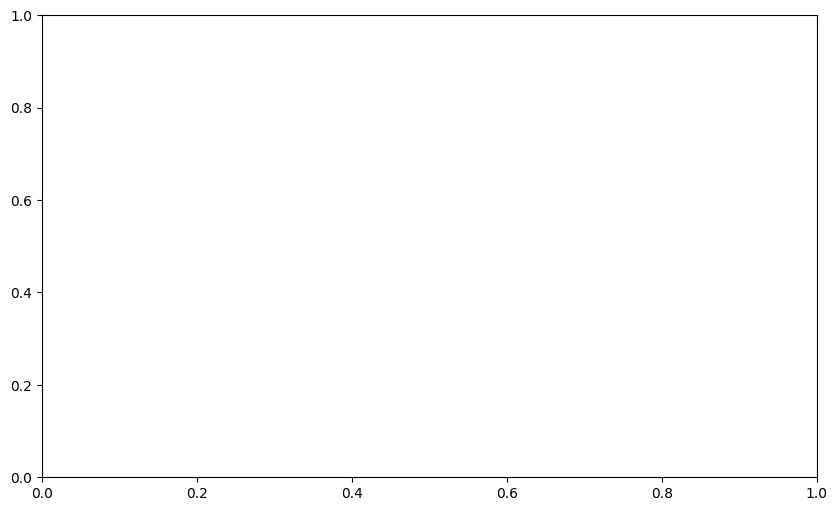

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ecc71" if x == results['RMSE'].min() else "#3498db" for x in results['RMSE']]
bars = ax.bar(results["Model"], results["RMSE"], color=colors, edgecolor="black", linewidth=1.5, alpha=0.8)

ax.set_title("Model Comparison — Root Mean Squared Error (RMSE)", fontsize=13, fontweight="bold")
ax.set_ylabel("RMSE (Lower is Better)", fontsize=11, fontweight="bold")
ax.set_xlabel("Model", fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, results["RMSE"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


NameError: name 'results' is not defined

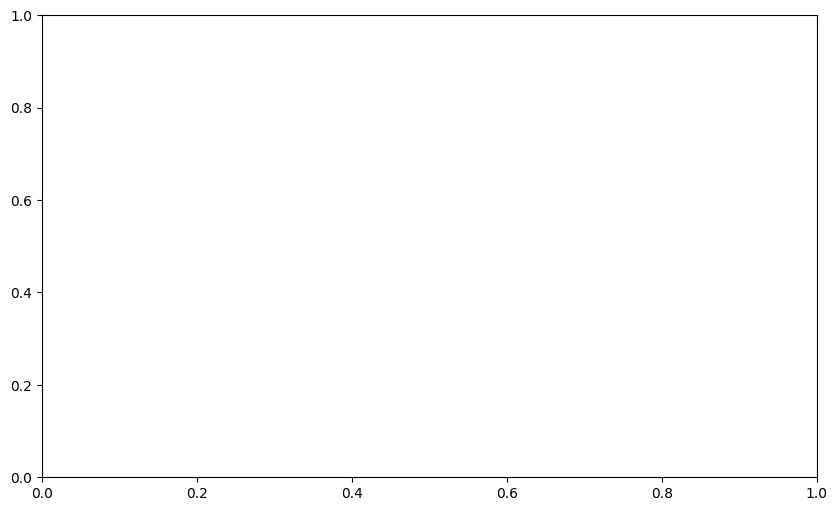

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ecc71" if x == results['R2'].max() else "#e74c3c" for x in results['R2']]
bars = ax.bar(results["Model"], results["R2"], color=colors, edgecolor="black", linewidth=1.5, alpha=0.8)

ax.set_title("Model Comparison — R² Score", fontsize=13, fontweight="bold")
ax.set_ylabel("R² (Higher is Better)", fontsize=11, fontweight="bold")
ax.set_xlabel("Model", fontsize=11, fontweight="bold")
ax.set_ylim([0, 1])
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, results["R2"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


NameError: name 'results' is not defined

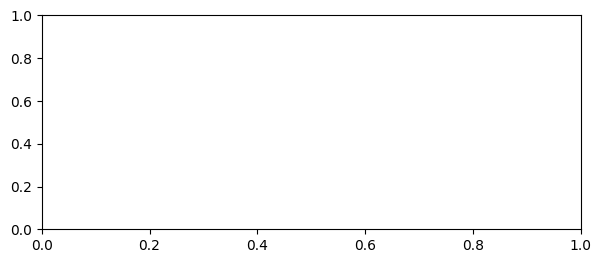

In [45]:
# Comprehensive model comparison dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. RMSE Comparison
ax1 = fig.add_subplot(gs[0, 0])
colors_rmse = ["#2ecc71" if x == results['RMSE'].min() else "#3498db" for x in results['RMSE']]
ax1.bar(results["Model"], results["RMSE"], color=colors_rmse, edgecolor="black", linewidth=1.5, alpha=0.8)
ax1.set_title("RMSE Comparison", fontsize=12, fontweight="bold")
ax1.set_ylabel("RMSE (Lower is Better)", fontsize=10)
ax1.tick_params(axis="x", rotation=30)
ax1.grid(axis="y", alpha=0.3)

# 2. R² Comparison
ax2 = fig.add_subplot(gs[0, 1])
colors_r2 = ["#2ecc71" if x == results['R2'].max() else "#e74c3c" for x in results['R2']]
ax2.bar(results["Model"], results["R2"], color=colors_r2, edgecolor="black", linewidth=1.5, alpha=0.8)
ax2.set_title("R² Score Comparison", fontsize=12, fontweight="bold")
ax2.set_ylabel("R² (Higher is Better)", fontsize=10)
ax2.set_ylim([0, 1])
ax2.tick_params(axis="x", rotation=30)
ax2.grid(axis="y", alpha=0.3)

# 3. MAE Comparison
ax3 = fig.add_subplot(gs[1, 0])
colors_mae = ["#2ecc71" if x == results['MAE'].min() else "#f39c12" for x in results['MAE']]
ax3.bar(results["Model"], results["MAE"], color=colors_mae, edgecolor="black", linewidth=1.5, alpha=0.8)
ax3.set_title("MAE Comparison", fontsize=12, fontweight="bold")
ax3.set_ylabel("MAE (Lower is Better)", fontsize=10)
ax3.tick_params(axis="x", rotation=30)
ax3.grid(axis="y", alpha=0.3)

# 4. Normalized Scores (Radar-like comparison)
ax4 = fig.add_subplot(gs[1, 1])
results_normalized = results.copy()
results_normalized['RMSE_norm'] = 1 - (results['RMSE'] / results['RMSE'].max())
results_normalized['R2_norm'] = results['R2']
results_normalized['MAE_norm'] = 1 - (results['MAE'] / results['MAE'].max())
results_normalized['Avg_Score'] = (results_normalized['RMSE_norm'] + results_normalized['R2_norm'] + results_normalized['MAE_norm']) / 3

colors_score = plt.cm.RdYlGn(results_normalized['Avg_Score'] / results_normalized['Avg_Score'].max())
ax4.bar(results["Model"], results_normalized['Avg_Score'], color=colors_score, edgecolor="black", linewidth=1.5, alpha=0.8)
ax4.set_title("Overall Model Score (Normalized)", fontsize=12, fontweight="bold")
ax4.set_ylabel("Composite Score", fontsize=10)
ax4.tick_params(axis="x", rotation=30)
ax4.grid(axis="y", alpha=0.3)

# 5. Metrics Table
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
table_data = results.values.astype(str)
table = ax5.table(cellText=table_data, colLabels=results.columns, 
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Color header
for i in range(len(results.columns)):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(results) + 1):
    for j in range(len(results.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')

plt.suptitle("Comprehensive Model Evaluation Dashboard", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()


In [46]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Page config
# ----------------------------
st.set_page_config(page_title="Life Satisfaction Explorer", layout="wide")

st.title("📊 Life Satisfaction – Interactive Analysis (Lite Project)")

# ----------------------------
# Load cleaned data
# ----------------------------
@st.cache_data
def load_data():
    return pd.read_csv("health_dataset.csv")

df = load_data()

# ----------------------------
# Sidebar
# ----------------------------
st.sidebar.header("Controls")

tab = st.sidebar.radio(
    "Select View",
    ["📋 Dataset Overview", "📊 Interactive EDA", "🤖 Model Comparison"]
)

# ----------------------------
# Columns used in lite project
# ----------------------------
target = "Life_satisfaction"

features = [
    "Age",
    "Gender",
    "Marital_status",
    "Edu_level",
    "Total_income",
    "Gen_health_state",
    "Mental_health_state",
    "Stress_level",
    "Total_physical_act_time",
    "Smoked"
]

# ----------------------------
# TAB 1 — Dataset Overview
# ----------------------------
if tab == "📋 Dataset Overview":
    st.subheader("Dataset Overview")

    col1, col2 = st.columns(2)

    with col1:
        st.metric("Rows", df.shape[0])
        st.metric("Columns", df.shape[1])

    with col2:
        st.write("### Columns Used")
        st.write([target] + features)

    st.write("### Preview of Data")
    st.dataframe(df[[target] + features].head(20))

# ----------------------------
# TAB 2 — Interactive EDA
# ----------------------------
elif tab == "📊 Interactive EDA":
    st.subheader("Interactive Exploratory Data Analysis")

    feature = st.selectbox("Select Feature", features)

    plot_type = st.selectbox(
        "Select Plot Type",
        ["Histogram", "Boxplot", "Scatter Plot"]
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    # Histogram
    if plot_type == "Histogram":
        sns.histplot(df[target], bins=10, kde=True, ax=ax)
        ax.set_title(f"Distribution of {target}")

    # Boxplot
    elif plot_type == "Boxplot":
        sns.boxplot(
            data=df,
            x=feature,
            y=target,
            ax=ax
        )
        ax.set_title(f"{target} vs {feature}")
        plt.xticks(rotation=30)

    # Scatter plot (only numeric)
    elif plot_type == "Scatter Plot":
        if feature == "Total_physical_act_time" or feature == "Age":
            sns.scatterplot(
                data=df,
                x=feature,
                y=target,
                alpha=0.4,
                ax=ax
            )
            ax.set_title(f"{target} vs {feature}")
        else:
            st.warning("Scatter plot is only available for numeric features.")
            st.stop()

    st.pyplot(fig)

# ----------------------------
# TAB 3 — Model Comparison
# ----------------------------
else:
    st.subheader("Model Comparison Results")

    results = pd.DataFrame({
        "Model": [
            "Linear Regression",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting"
        ],
        "MAE": [1.1986, 1.0624, 1.0497, 1.0678],
        "RMSE": [1.8172, 1.8580, 1.9271, 1.7754],
        "R2": [0.5569, 0.5368, 0.5017, 0.5770]
    })

    st.dataframe(results)

    st.success("🏆 Best Model: Gradient Boosting Regressor")


2025-12-15 09:13:33.670 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-15 09:13:33.670 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-15 09:13:34.285 
  command:

    streamlit run C:\Users\savin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-12-15 09:13:34.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-15 09:13:34.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-15 09:13:34.297 No runtime found, using MemoryCacheStorageManager
2025-12-15 09:13:34.303 No runtime found, using MemoryCacheStorageManager
2025-12-15 09:13:34.306 Thread 'MainThread': missing ScriptRunConte